In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### System message를 통해 더 나은 챗봇 구축
웹서치를 llm이 언제 사용할건지?
- 도구를 활용할때 어떤점을 유의해야할지 system message에 적어준다. 더 적절하게 사용하기 위함이다.
- 언제 web_search 도구가 유용한지 prompt를 넣어준다. 
1. real_time_info, 
2. local_specialize_info(특정 지역문화 에 관한 정보들)
3. metic_related_info (수치와 같은 정보들))
- 어떤점을 유의해야할지 가이드를 작성해준다.

In [2]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from datetime import datetime
from langchain_community.tools.tavily_search import TavilySearchResults

system_prompt = f"""
You are a helpful AI Assistant that can use web search tool(tavily ai api).
You should always answer in same language as user's ask
When use ask about the information that you can't answer, you should call the web search tool.

web search tools is useful when:
- real-time info
- local specialized info
- metric related info

you should use websearch tool with the guideline below:
- Extreact the user query's intent and rephrase the promptinto appropriate search query
- web search tool(Tavliy AI API) can deal with sentence query.
you don't need to linit your querying ability to generating keyword only query.
- Tolda is {datetime.now().strftime("%Y-%m-%d")}

"""

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(system_prompt),
    HumanMessagePromptTemplate.from_template("{input}")
])

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

search = TavilySearchResults(max_results=2)
tools = [search]
llm_with_tools = llm.bind_tools(tools)

chain = prompt | llm_with_tools
# tool_call을 호출
result = chain.invoke({"input":"랭그래프에 대한 최신뉴스 알려줘"})
print(result)

content='' additional_kwargs={'tool_calls': [{'id': 'call_9fqgEfb5jVLiT4rgLGZArgjH', 'function': {'arguments': '{"query":"랭그래프 최신 뉴스"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 232, 'total_tokens': 255, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0705bf87c0', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-acca36aa-18a7-4462-90ed-446fa4b20767-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '랭그래프 최신 뉴스'}, 'id': 'call_9fqgEfb5jVLiT4rgLGZArgjH', 'type': 'tool_call'}] usage_metadata={'input_tokens': 232, 'output_tokens': 23, 'total_tokens': 255, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details'

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph, add_messages
from langgraph.prebuilt import tools_condition, ToolNode

class State(TypedDict):
    messages : Annotated[list, add_messages]
    
def chatbot(state: State):
    answer = chain.invoke(state["messages"])
    return {"messages": [answer]}

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

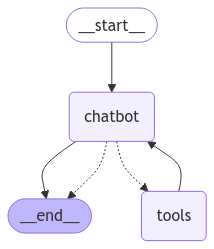

In [4]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

langgraph기사 알려줘
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_8CtuBYwivWl4U0akvmzefhGw)
 Call ID: call_8CtuBYwivWl4U0akvmzefhGw
  Args:
    query: langgraph 기사
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://blog.langchain.dev/langgraph-studio-the-first-agent-ide/", "content": "LangGraph Studio offers a new way to develop LLM applications, providing a specialized agent IDE for visualizing, interacting with, and debugging complex agentic applications. In this blog, we'll give a brief overview of LangGraph and then explore how LangGraph Studio streamlines the development of agentic applications."}, {"url": "https://www.datacamp.com/tutorial/langgraph-tutorial", "content": "LangGraph can be used to build a wide range of applications. Chatbots. 

In [6]:
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

최근 상영 인기영화 알려줘
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_OmeS4KoEkVx074YO9Pyt7F6e)
 Call ID: call_OmeS4KoEkVx074YO9Pyt7F6e
  Args:
    query: 최근 상영 인기 영화
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://m.blog.naver.com/nyria99/223633683798", "content": "상영 중인 최신 극장 개봉 영화 순위 (2024년 10월 4주차) : 네이버 블로그 상영 중인 최신 극장 개봉 영화 순위 (2024년 10월 4주차) 영화진흥위원회 통합전산망 집계에 따르면, 10월 23일 개봉한 영화 '베놈: 라스트 댄스'는 개봉 당일 12만 명의 관객을 동원해 전체 박스오피스 1위를 차지했고, 이후 예매율 또한 2위 <보통의 가족>보다 10배 이상 높은 수치를 기록하고 있다고 합니다. [최신 영화 리뷰] 베놈: 라스트 댄스 (베놈3, 쿠키, 결말, 줄거리, 연령, 빌런)2024년 10월 23일에 개봉한 <베놈: 라스트 댄스>에 대한 리뷰입니다. [최신 영화 리뷰] 보통의 가족 (결말, 줄거리, 스포, 쿠키, 원작 '더 디너')2024년 10월 16일 개봉예정인 공포영화 <보통의 가족>에 대한 리뷰를 작성해 보겠습니다. {\"title\":\"상영 중인 최신 극장 개봉 영화 순위 (2024년 10월 4주차)\",\"source\":\"https://bl

In [7]:
question = ("내 이름은 김재호 입니다. 저는 정진원을 매우 사랑해서 나중에 결혼할 거에요. 만나서 반가워요")

for event in graph.stream({"messages": [("user", question)]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

안녕하세요, 김재호님! 정진원과의 사랑이 깊으시군요. 결혼 계획도 세우고 계신다니 정말 축하드립니다! 만나서 반가워요. 어떤 이야기를 나누고 싶으신가요?


In [8]:
question = ("내 이름은 김재호 입니다. 저는 정진원을 매우 사랑해서 나중에 결혼할 거에요. 만나서 반가워요")

for event in graph.stream({"messages": [("user", input("User: "))]}, config=config):
    for value in event.values():
        value["messages"][-1].pretty_print()

================================== Ai Message ==================================

진원이에 대한 사랑을 표현하셨군요! 사랑은 정말 아름다운 감정입니다. 진원이에 대해 더 이야기하고 싶으신가요?


# Custom_tool을 설정을 통한 도구 통제성향상.

In [9]:
from langchain_core.tools import tool
from tavily import TavilyClient
import os

@tool
def search_news(keyword: str)-> str:
    """Collect recent news for the given query."""
    tavily_client = TavilyClient(api_key=os.environ['TAVILY_API_KEY'])
    search_results = tavily_client.search(query=keyword, topic="news", days=30)
    return search_results

In [10]:
llm = ChatOpenAI(
    model = "gpt-4o-mini",
    temperature=0
)
tools = [search_news]
llm_with_tools = llm.bind_tools(tools)

In [11]:
class State(TypedDict):
    messages : Annotated[list, add_messages]
    
def chatbot(state: State):
    answer = llm_with_tools.invoke(state["messages"])
    return {"messages": [answer]}

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

# 도구 노드 추가
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# 조건부 엣지 추가
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

# 도구 호출 후 채팅봇으로 돌아가는 엣지 추가
graph_builder.add_edge("tools", "chatbot")

# 시작점 설정
graph_builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph = graph_builder.compile()

In [12]:
# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

최근 상영 인기영화 알려줘
================================== Ai Message ==================================
Tool Calls:
  search_news (call_ayKbBcfVU7QJngwmw5VO3gNb)
 Call ID: call_ayKbBcfVU7QJngwmw5VO3gNb
  Args:
    keyword: 최근 상영 인기 영화
================================= Tool Message =================================
Name: search_news

{"query": "최근 상영 인기 영화", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.chicagotribune.com/2024/11/10/heretic-and-hugh-grant-debut-with-11-million-but-venom-the-last-dance-tops-box-office-again/", "title": "‘Heretic’ and Hugh Grant debut with $11 million, but ‘Venom: The Last Dance’ tops box office again - Chicago Tribune", "score": 0.33133605, "published_date": "Sun, 10 Nov 2024 18:54:39 GMT", "content": "For the third weekend in a row, “Venom: The Last Dance” was the No. 1 movie at the box office, collecting $16.2 million in ticket sales 

In [13]:
# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

최근 langgraph기사 알려줘
================================== Ai Message ==================================
Tool Calls:
  search_news (call_3Da3EuvHY2jDKcOqmF29NSt6)
 Call ID: call_3Da3EuvHY2jDKcOqmF29NSt6
  Args:
    keyword: langgraph
================================= Tool Message =================================
Name: search_news

{"query": "langgraph", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nature.com/articles/s41534-024-00900-2", "title": "Classification of dynamical Lie algebras of 2-local spin systems on linear, circular and fully connected topologies - Nature.com", "score": 0.13477592, "published_date": "Wed, 06 Nov 2024 20:31:53 GMT", "content": "\\({\\mathfrak{a}}\\), \\({\\mathfrak{g}}\\)Lie algebras.\\({\\mathcal{A}}\\), \\({\\mathcal{G}}\\)Sets, usually generating sets for Lie algebras.\\({\\langle {\\mathcal{G}}\\rangle }_{{\\rm{Lie}}}\\)The Lie 